# Data Visualisation & Feature Exploration
Dynamic Urban Traffic Prediction — EDA notebook.

Goal of this notebook: go beyond simple distribution plots and actually **decide which features matter for predicting `Vehicle Count`**, so Phase 4 (Feature Engineering) and Phase 6 (XGBoost training) start from an informed feature list instead of guessing.

### Library Import

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

### Load Cleaned Dataset
Uses a relative path (`../../data/...`) so this notebook runs on any teammate's machine, not just the original author's `C:\Users\KIIT\...` path.

In [2]:
DATA_PATH = os.path.join("..", "..", "data", "traffic_dataset_clean.csv")
data = pd.read_csv(DATA_PATH)
print("Shape:", data.shape)
data.head()

Shape: (4354, 14)


,Timestamp,Vehicle Count,Avg Speed (km/h),Vehicle Density (%),Saturation Flow Rate(veh/hr/lane),Volume to Saturation Lane Traffic ratio(%),FreeFlowSpeed (km/h),TSR,VLSR,Speed Factor,CI,Congestion Level,Hour,Previous_Traffic
0,8:00:00,97,31.2,40,1800,1.347222,50,0.376,0.013472,0.624,0.240589,Moderate,8,97.0
1,8:01:00,126,48.5,57,1800,1.750000,50,0.030,0.017500,0.970,0.241000,Moderate,8,97.0
2,8:02:00,61,42.0,82,1800,0.847222,50,0.160,0.008472,0.840,0.363389,High,8,126.0
3,8:03:00,170,38.0,75,1800,2.361111,50,0.240,0.023611,0.760,0.357444,High,8,61.0
4,8:04:00,180,24.7,90,1800,2.500000,50,0.506,0.025000,0.494,0.471200,Very High,8,170.0


In [3]:
data.dtypes

Timestamp                                          str
Vehicle Count                                    int64
Avg Speed (km/h)                               float64
Vehicle Density (%)                              int64
Saturation Flow Rate(veh/hr/lane)                int64
Volume to  Saturation Lane Traffic ratio(%)    float64
FreeFlowSpeed (km/h)                             int64
TSR                                            float64
VLSR                                           float64
Speed Factor                                   float64
CI                                             float64
Congestion Level                                   str
Hour                                             int64
Previous_Traffic                               float64
dtype: object

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Vehicle Count,4354.0,125.081994,43.230983,50.000000,88.000000,125.000000,162.000000,200.000000
Avg Speed (km/h),4354.0,34.926757,8.692768,20.000000,27.400000,35.050000,42.400000,50.000000
Vehicle Density (%),4354.0,59.796279,17.800153,30.000000,44.000000,60.000000,75.000000,90.000000
Saturation Flow Rate(veh/hr/lane),4354.0,1800.000000,0.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
Volume to Saturation Lane Traffic ratio(%),4354.0,1.737250,0.600430,0.694444,1.222222,1.736111,2.250000,2.777778
FreeFlowSpeed (km/h),4354.0,50.000000,0.000000,50.000000,50.000000,50.000000,50.000000,50.000000
TSR,4354.0,0.301465,0.173855,0.000000,0.152000,0.299000,0.452000,0.600000
VLSR,4354.0,0.017372,0.006004,0.006944,0.012222,0.017361,0.022500,0.027778
Speed Factor,4354.0,0.698535,0.173855,0.400000,0.548000,0.701000,0.848000,1.000000
CI,4354.0,0.306427,0.079303,0.123689,0.244708,0.305628,0.366706,0.487511


## 1. Target Variable: `Vehicle Count`
Everything downstream (XGBoost regression, congestion thresholds) depends on this column, so understand its shape and its behaviour over time first.

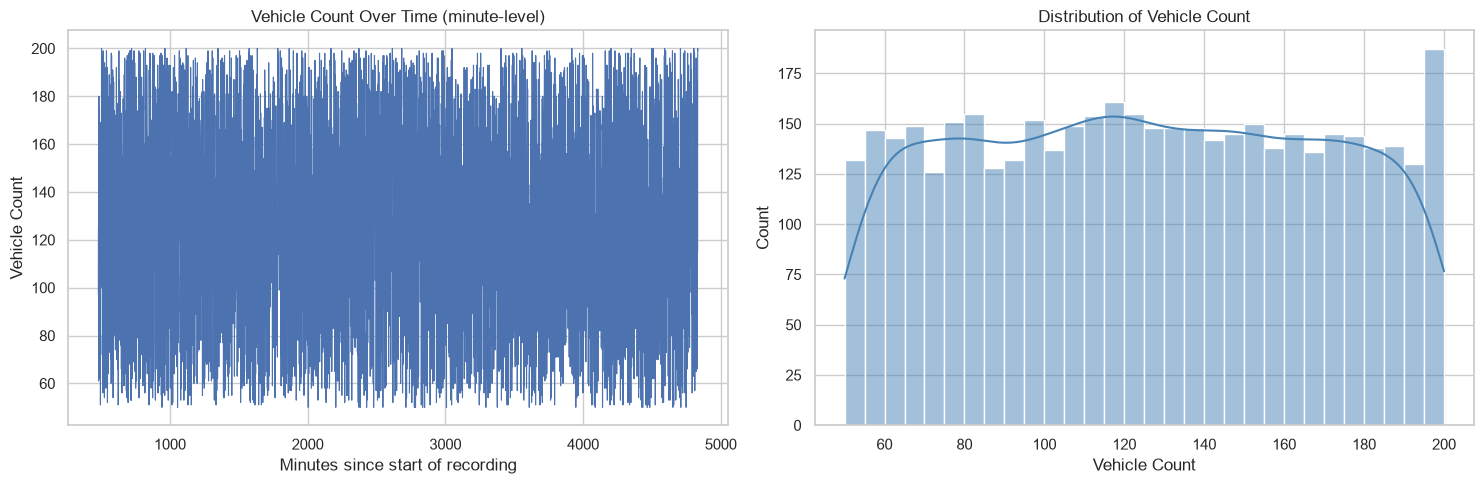

In [5]:
data["Time"] = pd.to_timedelta(data["Timestamp"].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(data["Time"].dt.total_seconds() / 60, data["Vehicle Count"], linewidth=0.8)
axes[0].set_title("Vehicle Count Over Time (minute-level)")
axes[0].set_xlabel("Minutes since start of recording")
axes[0].set_ylabel("Vehicle Count")

sns.histplot(data["Vehicle Count"], bins=30, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Distribution of Vehicle Count")
axes[1].set_xlabel("Vehicle Count")

plt.tight_layout()
plt.show()

**Why this matters:** the raw time-series plot shows whether traffic is noisy/spiky (favours lag + rolling-mean features) or smoothly cyclical (favours hour-of-day encoding). The histogram tells you if the target is skewed — if it is, note it for Phase 6 (XGBoost handles skew reasonably well, but it's still worth knowing before picking evaluation metrics).

## 2. Correlation Heatmap — Which Features Actually Relate to `Vehicle Count`?
This is the single most useful chart for feature selection: it tells you what to *keep* for modelling and what's likely redundant (e.g. two features that are ~1.0 correlated with each other add little beyond the first).

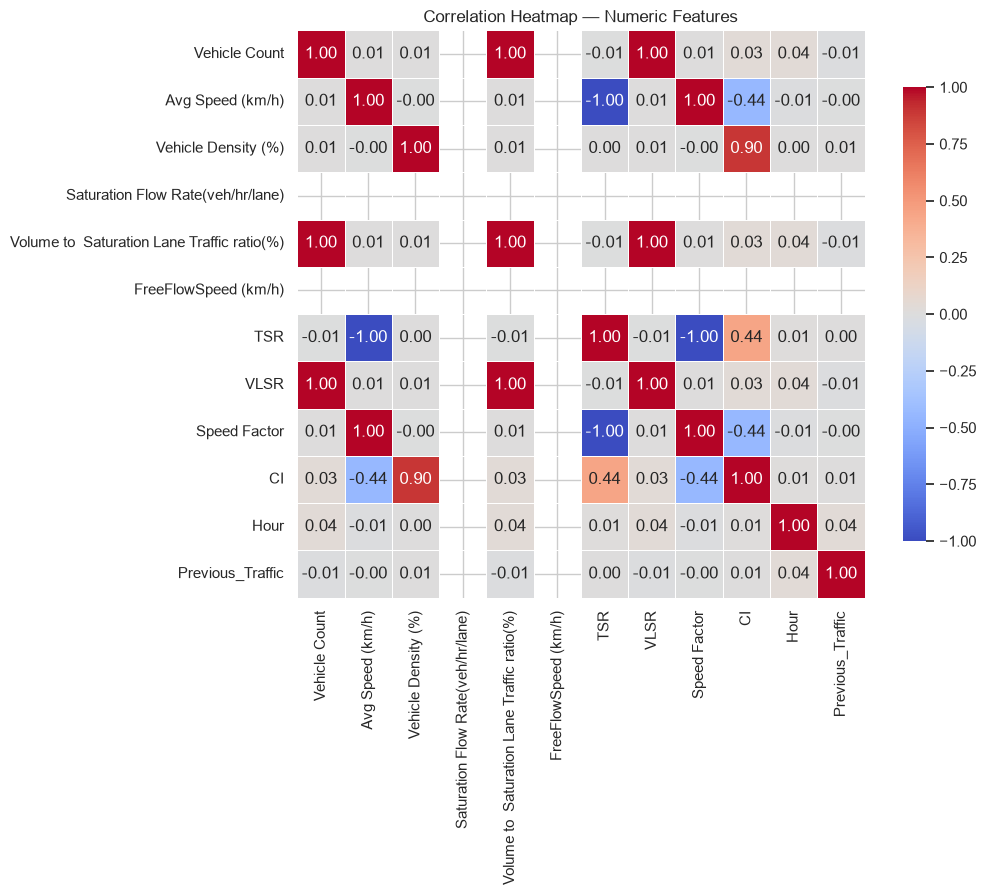

In [6]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "Time"]  # exclude timedelta helper column
corr = data[numeric_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

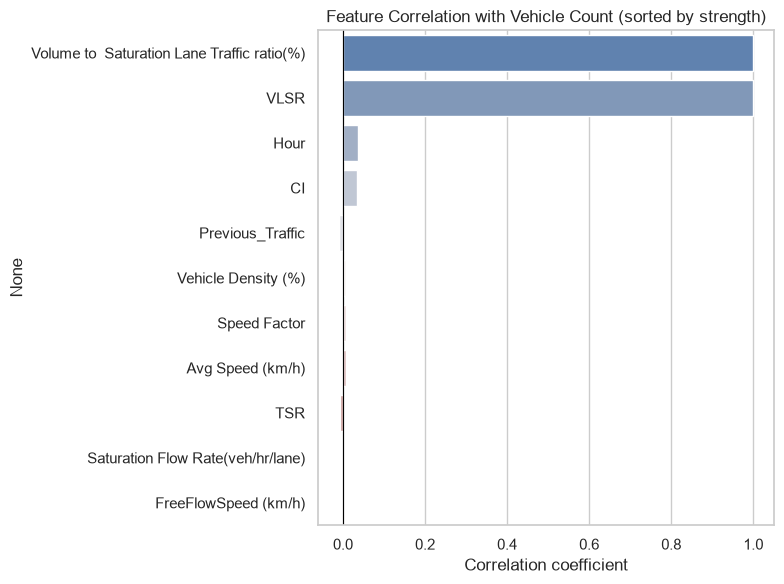

Volume to  Saturation Lane Traffic ratio(%)    1.000000
VLSR                                           1.000000
Hour                                           0.037422
CI                                             0.034051
Previous_Traffic                              -0.009429
Vehicle Density (%)                            0.007408
Speed Factor                                   0.006582
Avg Speed (km/h)                               0.006582
TSR                                           -0.006582
Saturation Flow Rate(veh/hr/lane)                   NaN
FreeFlowSpeed (km/h)                                NaN
Name: Vehicle Count, dtype: float64

In [7]:
target_corr = corr["Vehicle Count"].drop("Vehicle Count").sort_values(key=np.abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=target_corr.values, y=target_corr.index,
            hue=target_corr.index, palette="vlag", legend=False)
plt.title("Feature Correlation with Vehicle Count (sorted by strength)")
plt.xlabel("Correlation coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

target_corr

**Reading this chart:** features near the top (either strongly positive or strongly negative) are the ones most worth keeping for XGBoost. Features close to 0 aren't necessarily useless (XGBoost can pick up non-linear relationships a linear correlation misses), but they're candidates to double-check with the mutual-information chart in Section 6.

## 3. Feature Distributions (by Feature Group)
Grouped so related features sit together, instead of one long, unstructured stack of histograms.

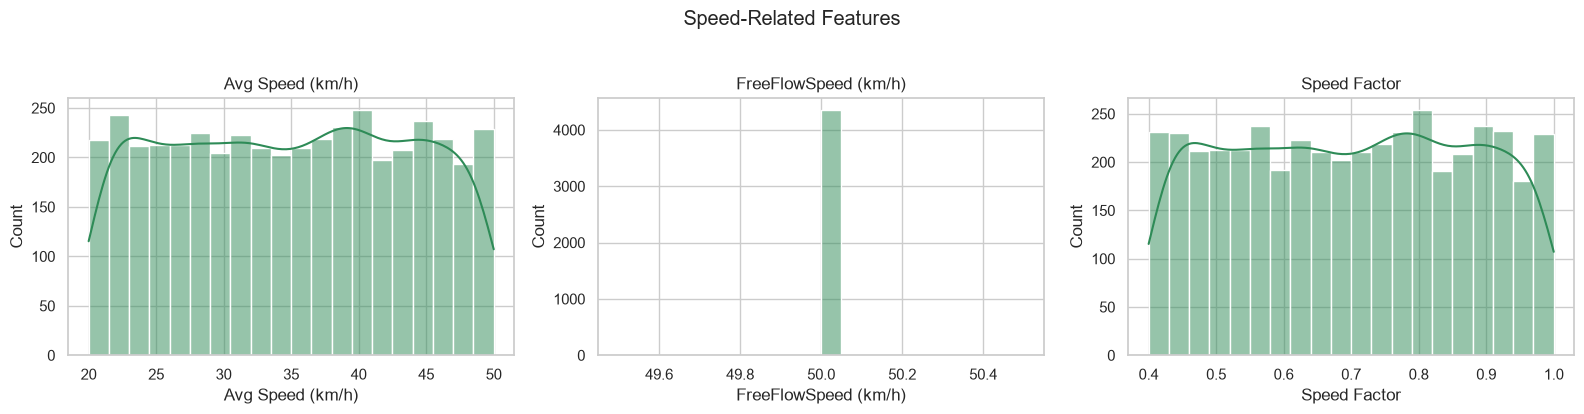

In [8]:
speed_flow_cols = ["Avg Speed (km/h)", "FreeFlowSpeed (km/h)", "Speed Factor"]
fig, axes = plt.subplots(1, len(speed_flow_cols), figsize=(16, 4))
for ax, col in zip(axes, speed_flow_cols):
    sns.histplot(data[col], bins=20, kde=True, ax=ax, color="seagreen")
    ax.set_title(col)
plt.suptitle("Speed-Related Features", y=1.03)
plt.tight_layout()
plt.show()

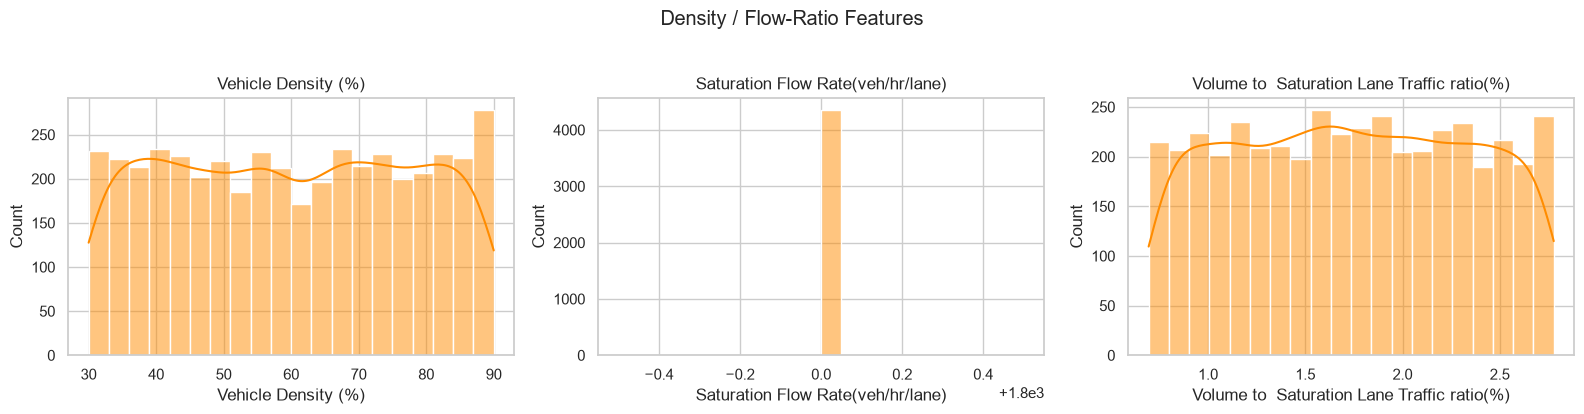

In [9]:
density_flow_cols = ["Vehicle Density (%)", "Saturation Flow Rate(veh/hr/lane)",
                     "Volume to  Saturation Lane Traffic ratio(%)"]
fig, axes = plt.subplots(1, len(density_flow_cols), figsize=(16, 4))
for ax, col in zip(axes, density_flow_cols):
    sns.histplot(data[col], bins=20, kde=True, ax=ax, color="darkorange")
    ax.set_title(col)
plt.suptitle("Density / Flow-Ratio Features", y=1.03)
plt.tight_layout()
plt.show()

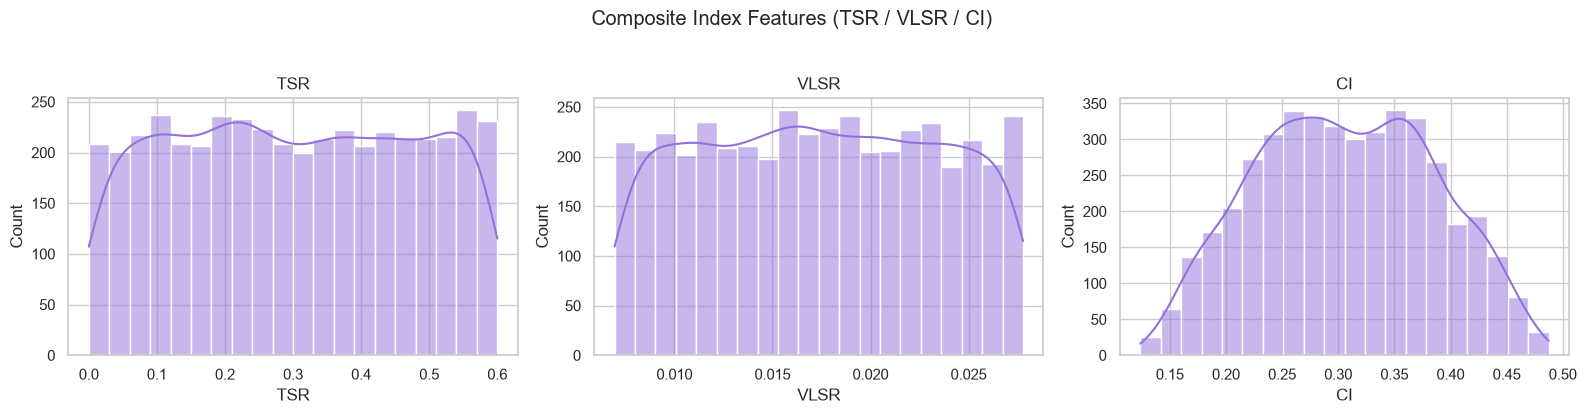

In [10]:
index_cols = ["TSR", "VLSR", "CI"]
fig, axes = plt.subplots(1, len(index_cols), figsize=(16, 4))
for ax, col in zip(axes, index_cols):
    sns.histplot(data[col], bins=20, kde=True, ax=ax, color="mediumpurple")
    ax.set_title(col)
plt.suptitle("Composite Index Features (TSR / VLSR / CI)", y=1.03)
plt.tight_layout()
plt.show()

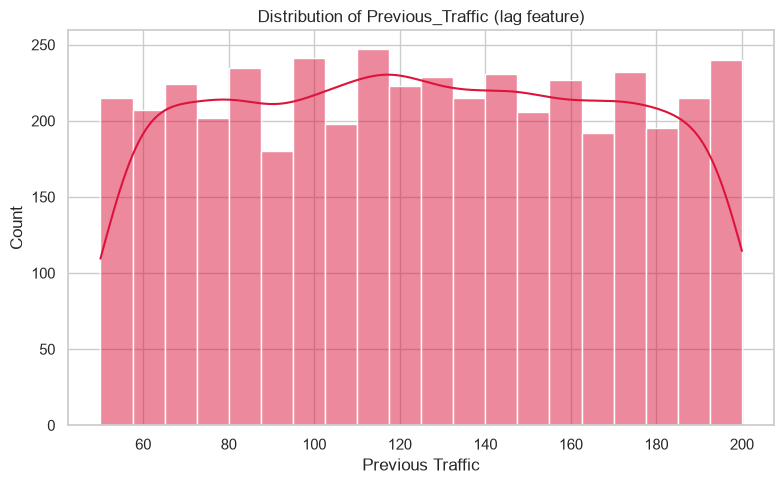

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Previous_Traffic"], bins=20, kde=True, color="crimson")
plt.title("Distribution of Previous_Traffic (lag feature)")
plt.xlabel("Previous Traffic")
plt.tight_layout()
plt.show()

## 4. Vehicle Count vs. Hour — The Rush-Hour Pattern
This is the pattern the model most needs to learn. A boxplot (rather than just a bar count of rows-per-hour) shows the actual spread of traffic volume at each hour, which is what justifies adding cyclical hour encoding in Phase 4.

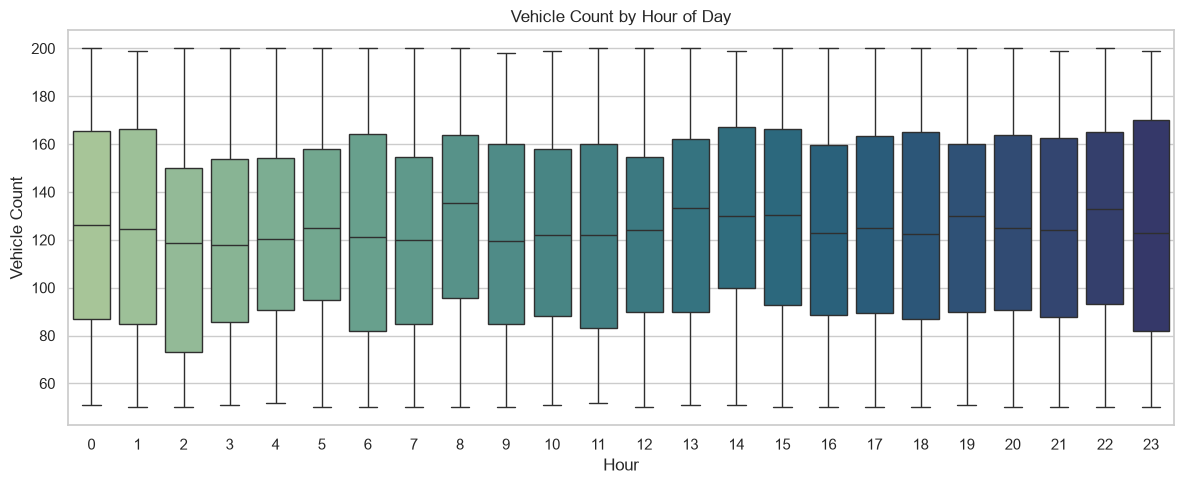

In [12]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=data, x="Hour", y="Vehicle Count", hue="Hour", palette="crest", legend=False)
plt.title("Vehicle Count by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Vehicle Count")
plt.tight_layout()
plt.show()

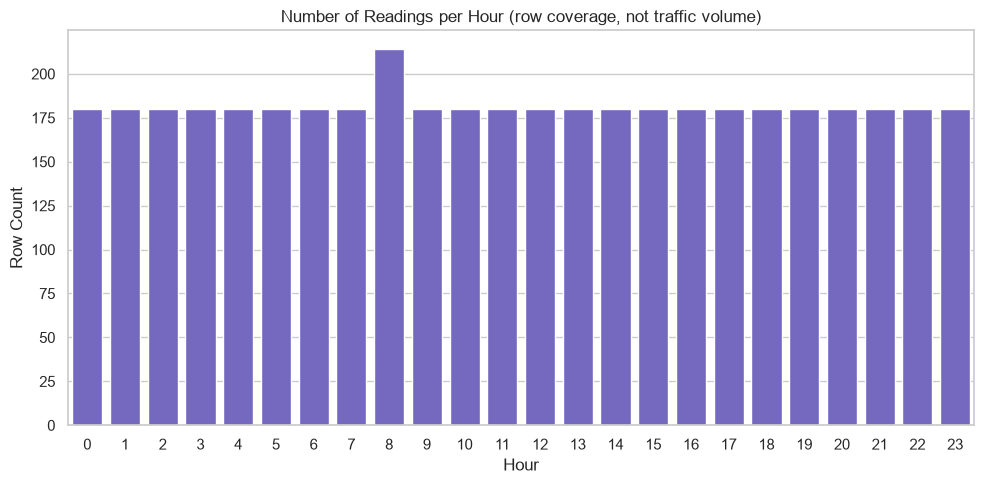

In [13]:
plt.figure(figsize=(10, 5))
hourly_counts = data["Hour"].value_counts().sort_index()
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, color="slateblue")
plt.title("Number of Readings per Hour (row coverage, not traffic volume)")
plt.xlabel("Hour")
plt.ylabel("Row Count")
plt.tight_layout()
plt.show()

## 5. Vehicle Count vs. Congestion Level — Sanity-Checking the Labels
Since Phase 8's Low/Moderate/High classification will be threshold-based on predicted `Vehicle Count`, the existing `Congestion Level` labels should roughly line up with volume. This boxplot is that sanity check, and the class-balance chart shows whether one label dominates (which affects how classification accuracy should be read later).

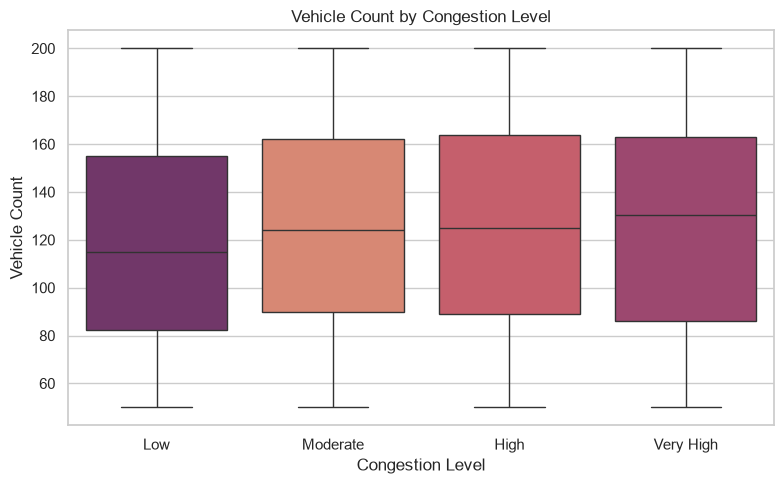

In [14]:
order = data.groupby("Congestion Level")["Vehicle Count"].median().sort_values().index

plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="Congestion Level", y="Vehicle Count", order=order,
            hue="Congestion Level", palette="flare", legend=False)
plt.title("Vehicle Count by Congestion Level")
plt.tight_layout()
plt.show()

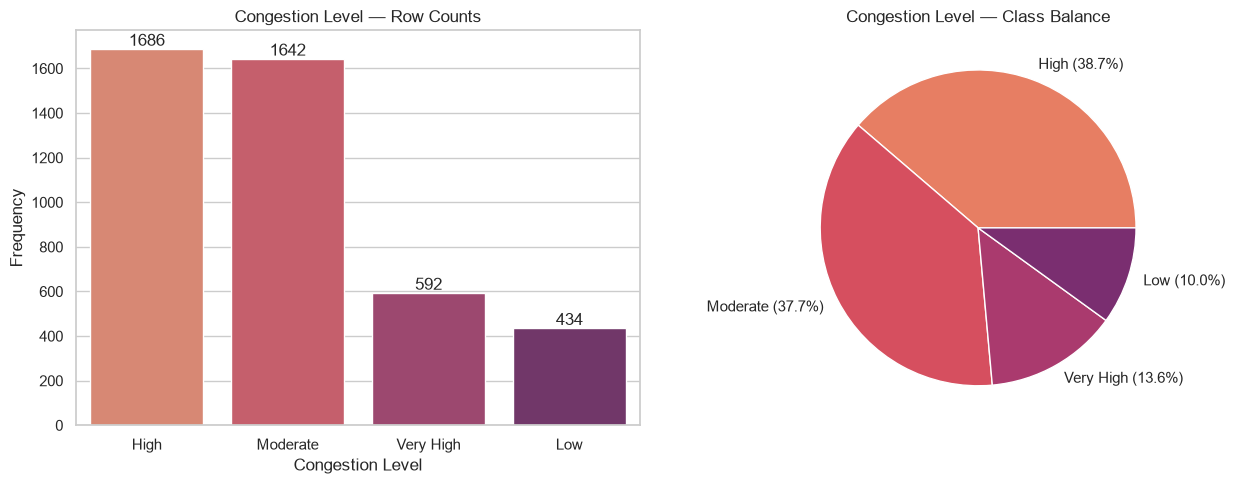

Congestion Level
High         38.7
Moderate     37.7
Very High    13.6
Low          10.0
Name: count, dtype: float64


In [15]:
counts = data["Congestion Level"].value_counts()
pct = (counts / counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="flare", legend=False, ax=axes[0])
axes[0].set_title("Congestion Level — Row Counts")
axes[0].set_ylabel("Frequency")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

axes[1].pie(counts.values, labels=[f"{idx} ({p}%)" for idx, p in zip(counts.index, pct)],
            colors=sns.color_palette("flare", len(counts)))
axes[1].set_title("Congestion Level — Class Balance")

plt.tight_layout()
plt.show()

print(pct)

## 6. Mutual Information — A Non-Linear Feature Importance Proxy
Correlation (Section 2) only captures *linear* relationships. XGBoost can exploit non-linear ones too, so mutual information gives a second, complementary view of which features carry predictive signal about `Vehicle Count` before any model is trained.

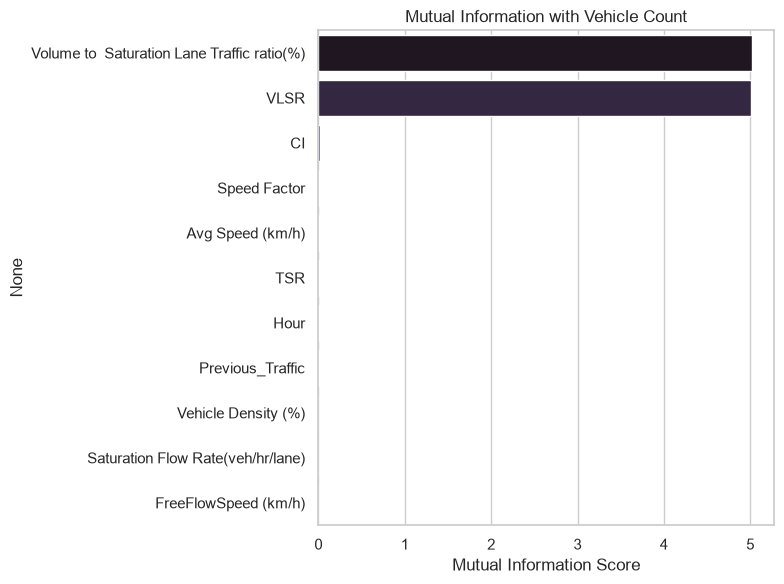

Volume to  Saturation Lane Traffic ratio(%)    5.024104
VLSR                                           5.004546
CI                                             0.020636
Speed Factor                                   0.007617
Avg Speed (km/h)                               0.005739
TSR                                            0.005092
Hour                                           0.003117
Previous_Traffic                               0.002806
Vehicle Density (%)                            0.000000
Saturation Flow Rate(veh/hr/lane)              0.000000
FreeFlowSpeed (km/h)                           0.000000
dtype: float64

In [16]:
from sklearn.feature_selection import mutual_info_regression

feature_cols = [c for c in numeric_cols if c != "Vehicle Count"]
X = data[feature_cols].fillna(0)
y = data["Vehicle Count"]

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=mi_series.values, y=mi_series.index, hue=mi_series.index, palette="mako", legend=False)
plt.title("Mutual Information with Vehicle Count")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()

mi_series

## 7. Scatter Matrix of the Top Correlated Features
Zooming in on the handful of features that scored highest in Sections 2 and 6, to visually check for linearity, non-linearity, or outliers before they go into the model.

Top features by |correlation| with Vehicle Count: ['Volume to  Saturation Lane Traffic ratio(%)', 'VLSR', 'Hour', 'CI']


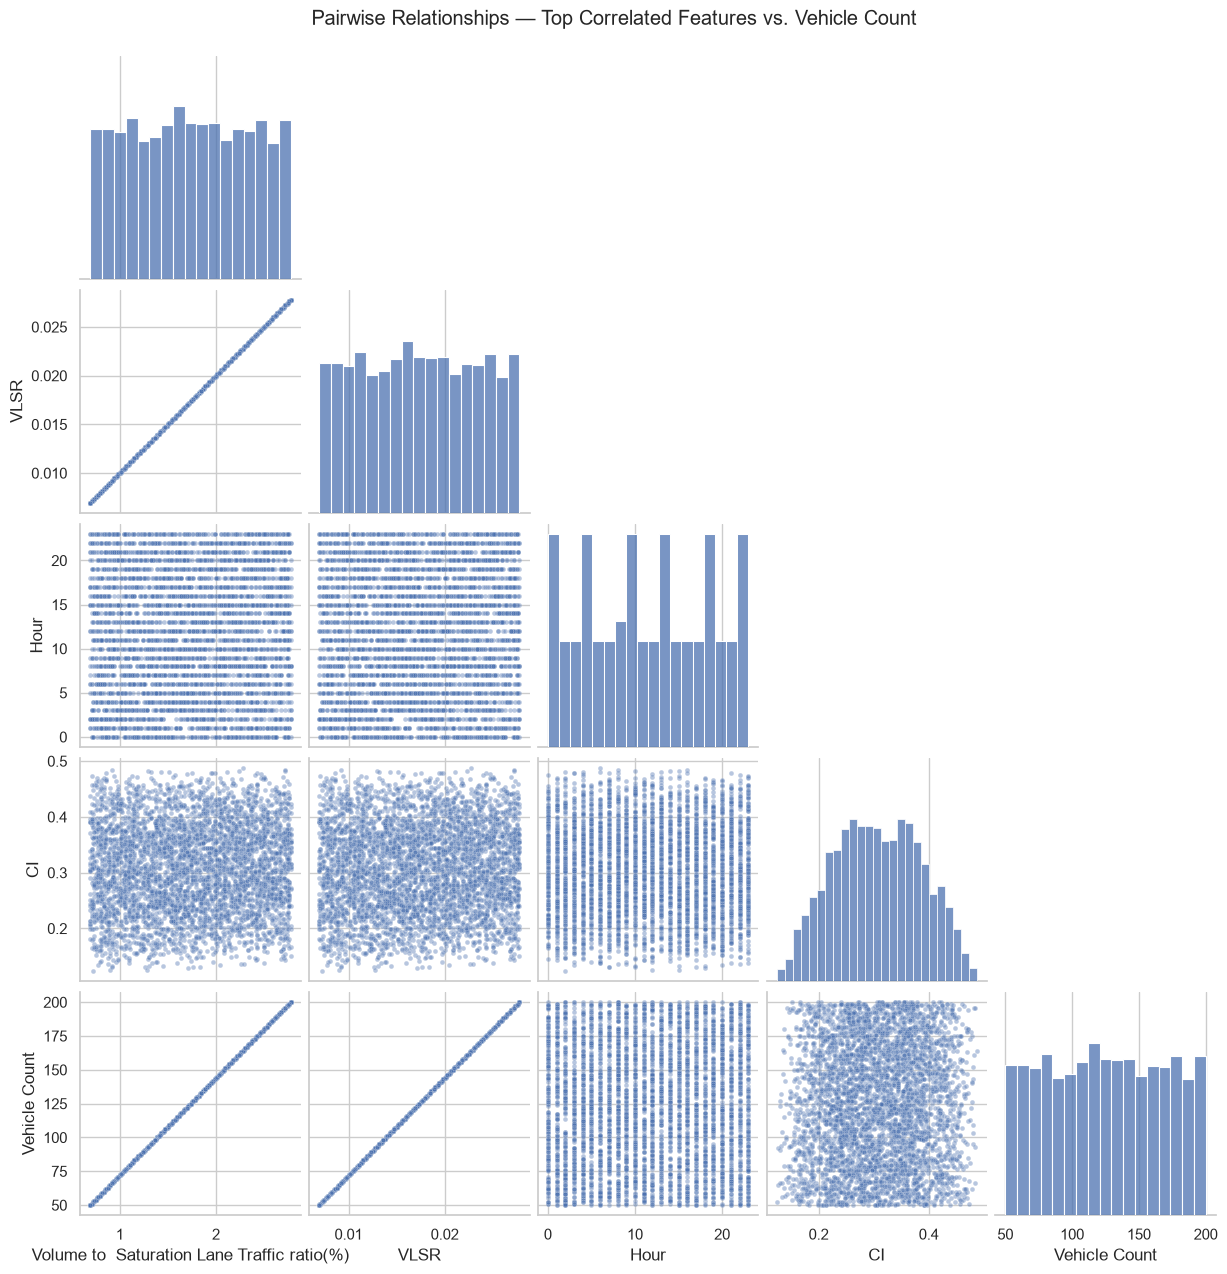

In [17]:
top_features = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()
print("Top features by |correlation| with Vehicle Count:", top_features)

plot_cols = top_features + ["Vehicle Count"]
sns.pairplot(data[plot_cols], corner=True, plot_kws={"alpha": 0.4, "s": 12})
plt.suptitle("Pairwise Relationships — Top Correlated Features vs. Vehicle Count", y=1.02)
plt.show()

## 8. Summary — What This Notebook Tells Us for Feature Engineering (Phase 4)
- **Keep**: whichever features rank highest in both the correlation chart (Section 2) *and* the mutual-information chart (Section 6) — agreement between the two is a strong signal.
- **Hour**: the boxplot in Section 4 shows a clear rush-hour pattern → justifies the planned `sin`/`cos` cyclical encoding of Hour.
- **Previous_Traffic**: typically one of the strongest predictors for a single-location time series like this one — supports adding more lag features (t-2, t-5) and a rolling mean, as already planned.
- **Day of week**: cannot be derived — the dataset has no date column, only a time-of-day `Timestamp`. This is a real scope limitation to state explicitly in the report/viva.
- **Congestion Level labels**: the boxplot in Section 5 confirms the given labels broadly track `Vehicle Count`, which supports using volume-based percentile thresholds in Phase 8 and citing agreement with the existing labels as validation.
- **Class imbalance**: check the percentages printed in Section 5 — if one class dominates, say so when interpreting later classification accuracy.